In [1]:
!pip install rioxarray pyproj

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.2/62.2 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 64.4 MB/s eta 0:00:00


In [2]:
import xarray as xr

In [8]:
!ls -lrt

total 376840
drwxr-xr-x 1 root root      4096 Jun 10 13:39 sample_data
-rw-r--r-- 1 root root 385875968 Jun 12 03:20 OPERA_L3_DISP-S1_IW_F22664_VV_20240527T125538Z_20241111T125537Z_v1.0_20250420T162803Z.nc


In [9]:
ds_opera = xr.open_dataset('OPERA_L3_DISP-S1_IW_F22664_VV_20240527T125538Z_20241111T125537Z_v1.0_20250420T162803Z.nc')

In [10]:
ds_opera

<xarray.Dataset> Size: 3GB
Dimensions:                         (y: 6951, x: 9650, time: 1)
Coordinates:
  * y                               (y) float64 56kB 3.689e+06 ... 3.481e+06
  * x                               (x) float64 77kB 4.768e+05 ... 7.663e+05
  * time                            (time) datetime64[ns] 8B 2024-11-11T12:55...
Data variables: (12/13)
    spatial_ref                     int64 8B ...
    reference_time                  (time) datetime64[ns] 8B ...
    displacement                    (y, x) float32 268MB ...
    short_wavelength_displacement   (y, x) float32 268MB ...
    recommended_mask                (y, x) float32 268MB ...
    connected_component_labels      (y, x) float32 268MB ...
    ...                              ...
    estimated_phase_quality         (y, x) float32 268MB ...
    persistent_scatterer_mask       (y, x) float32 268MB ...
    shp_counts                      (y, x) float32 268MB ...
    water_mask                      (y, x) float32 268MB ...
    phase_similarity                (y, x) float32 268MB ...
    timeseries_inversion_residuals  (y, x) float32 268MB ...
Attributes:
    Conventions:         CF-1.8
    contact:             opera-sds-ops@jpl.nasa.gov
    institution:         NASA JPL
    mission_name:        OPERA
    reference_document:  JPL D-108765
    title:               OPERA_L3_DISP-S1 Product

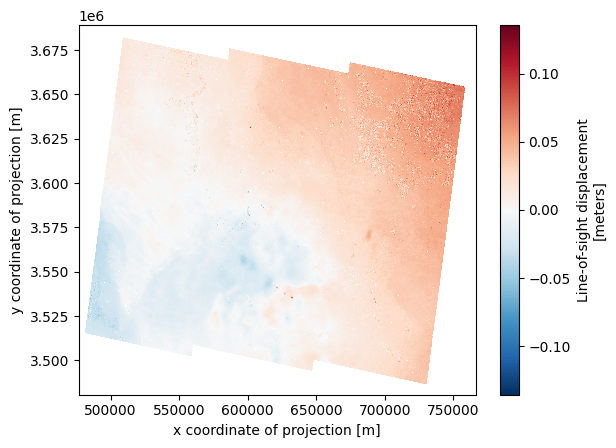

In [11]:
ds_opera.displacement.plot()

In [13]:
import xarray as xr
import rioxarray
from rasterio.warp import calculate_default_transform
import numpy as np

# Open dataset and select displacement
ds = xr.open_dataset("OPERA_L3_DISP-S1_IW_F22664_VV_20240527T125538Z_20241111T125537Z_v1.0_20250420T162803Z.nc")
disp = ds["displacement"]

# Set CRS using rioxarray
disp = disp.rio.write_crs("EPSG:32613") # Check this always

# Reproject to regular lat/lon grid (WGS84)
disp_latlon = disp.rio.reproject("EPSG:4326")

# Now create dataset with 1D lat/lon coords
# These will still be 2D, so reduce them
lat_1d = np.unique(disp_latlon.y.values)
lon_1d = np.unique(disp_latlon.x.values)

# Reassign with 1D coords
disp_1d = xr.DataArray(
    data=disp_latlon.values,
    dims=("lat", "lon"),
    coords={"lat": lat_1d, "lon": lon_1d},
    name="displacement"
)

# Wrap in Dataset
ds_1d = xr.Dataset({"displacement": disp_1d})

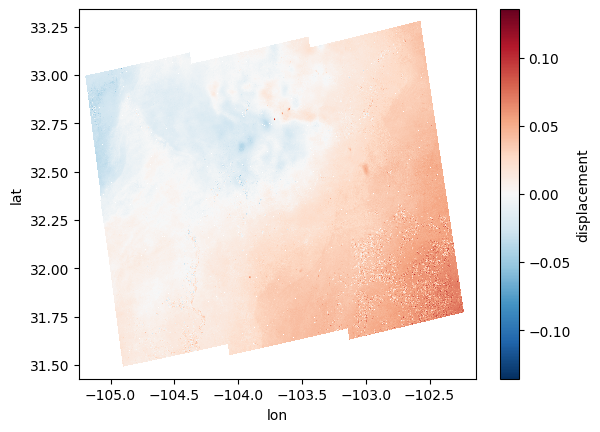

In [14]:
ds_1d.displacement.plot()

# Get the Sentinel 1 data

In [15]:
start_date = '20240527T125538Z'
end_date = '20241111T125537Z'

In [16]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [17]:
# INSTALLING REQUIRED LIBRARIES
!pip install -U pyproj -q
!pip install -U utm -q
!pip install -U google-colab -q
!pip install -U tornado -q
!pip install geemap -q
!pip install wxee

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 443.3/443.3 kB 7.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires tornado==6.4.2, but you have tornado 6.5.1 which is incompatible.


In [18]:
# !earthengine authenticate
import ee
import os

# Set the path to the service account key file
service_account = 'editor@ee-manmeet20singh15-wbis.iam.gserviceaccount.com'
key_file = 'drive/MyDrive/earth_engine/ee-manmeet20singh15-wbis-fab7f1ca35e0.json'

# Use the service account for authentication
credentials = ee.ServiceAccountCredentials(service_account, key_file)
ee.Initialize(credentials)

In [19]:
import ee
import wxee
#wxee.Initialize()

In [20]:
# lat_diff = 0
# lon_diff = 0
# aoi = ee.Geometry.Polygon(
#         [[[-125, 32],
#           [-113, 32],
#           [-113, 42],
#           [-125, 42]]])
# # aoi = ee.Geometry.Polygon(

In [21]:
# coords = aoi.coordinates().getInfo()[0]
# coords

In [22]:
# start_date = '2024-05-27'
# end_date = '2024-11-11'
# dataset = ee.ImageCollection('COPERNICUS/S1_GRD') \
#             .filterDate(start_date, end_date).select('VV')
# ds_sar = dataset.wx.to_xarray(region=aoi.bounds(), scale=69375)

# Deep Learning Computer Vision

In [23]:
# UNET
# Swin Transformer
# Vision Transformer
#
#
#
# Diffusion Models
# https://colab.research.google.com/drive/1uTjLA1EJ9yL52Wwstheq-oJKSeQTjXtu?usp=sharing

In [24]:
ds_1d

<xarray.Dataset> Size: 260MB
Dimensions:       (lat: 6315, lon: 10272)
Coordinates:
  * lat           (lat) float64 51kB 31.43 31.43 31.43 ... 33.34 33.34 33.34
  * lon           (lon) float64 82kB -105.2 -105.2 -105.2 ... -102.1 -102.1
Data variables:
    displacement  (lat, lon) float32 259MB nan nan nan nan ... nan nan nan nan

In [25]:
lat_diff = 0
lon_diff = 0
aoi = ee.Geometry.Polygon(
        [[[ds_1d.lon.values.max(), ds_1d.lat.values.min()],
          [ds_1d.lon.values.min(), ds_1d.lat.values.min()],
          [ds_1d.lon.values.min(), ds_1d.lat.values.max()],
          [ds_1d.lon.values.max(), ds_1d.lat.values.max()]]])

In [26]:
coords = aoi.coordinates().getInfo()[0]
coords

[[-105.24894905306857, 31.429758967461108],
 [-102.13960634966884, 31.429758967461108],
 [-102.13960634966884, 33.34119795385639],
 [-105.24894905306857, 33.34119795385639],
 [-105.24894905306857, 31.429758967461108]]

In [ ]:
start_date = '2024-05-27' # 20240527T125538
end_date = '2024-05-28' # 20241111T125537
dataset = ee.ImageCollection('COPERNICUS/S1_GRD') \
            .filterDate(start_date, end_date)
ds_s1 = dataset.wx.to_xarray(region=aoi.bounds(), scale=500) # 30 m is our target
# Break the AOI into smaller AOIs and run for loop and then concatenate all the small AOIs

Requesting data:   0%|          | 0/621 [00:00<?, ?it/s]

In [ ]:
start_date = '2024-11-11' # 20241111T125537
end_date = '2024-11-12' # 20241111T125537
dataset = ee.ImageCollection('COPERNICUS/S1_GRD') \
            .filterDate(start_date, end_date)
ds_s2 = dataset.wx.to_xarray(region=aoi.bounds(), scale=500) # 30 m is our target
# Break the AOI into smaller AOIs and run for loop and then concatenate all the small AOIs